In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mobile Reviews Sentiment.csv to Mobile Reviews Sentiment.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("Mobile Reviews Sentiment.csv")

print("Rows and Columns:", data.shape)

data.head()

Rows and Columns: (50000, 25)


,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2,...,True,1,1,3,2,1,46,7,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4,...,True,3,2,4,3,2,74,12,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4,...,True,3,5,3,2,4,55,11,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3,...,False,1,3,2,1,2,66,11,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3,...,True,3,3,2,2,1,73,12,0,BestBuy


In [4]:
#check dataset information
print("Columns:")
print(data.columns)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

Columns:
Index(['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd',
       'price_local', 'currency', 'exchange_rate_to_usd', 'rating',
       'review_text', 'sentiment', 'country', 'language', 'review_date',
       'verified_purchase', 'battery_life_rating', 'camera_rating',
       'performance_rating', 'design_rating', 'display_rating',
       'review_length', 'word_count', 'helpful_votes', 'source'],
      dtype='object')

Data Types:
review_id                 int64
customer_name            object
age                       int64
brand                    object
model                    object
price_usd               float64
price_local              object
currency                 object
exchange_rate_to_usd    float64
rating                    int64
review_text              object
sentiment                object
country                  object
language                 object
review_date              object
verified_purchase          bool
battery_life_rating       int6

In [5]:
sentiment_count = data["sentiment"].value_counts()

print(sentiment_count)

sentiment
Positive    27540
Neutral     12549
Negative     9911
Name: count, dtype: int64


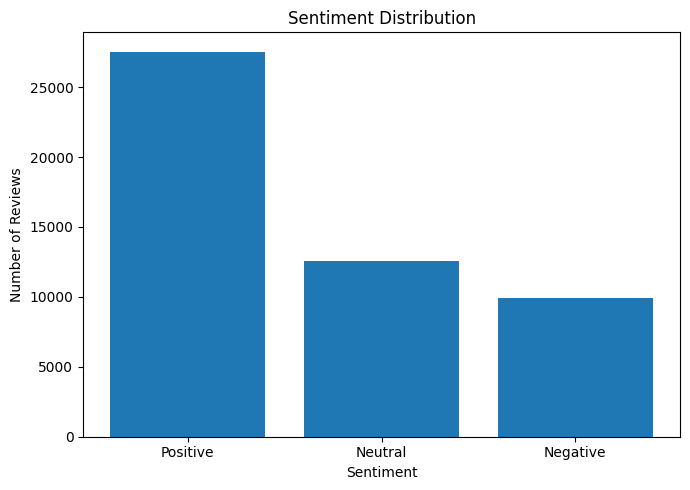

In [6]:
plt.figure(figsize=(7, 5))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [7]:
sentiment_percentage = data["sentiment"].value_counts(normalize=True) * 100

print(sentiment_percentage.round(2))

sentiment
Positive    55.08
Neutral     25.10
Negative    19.82
Name: proportion, dtype: float64


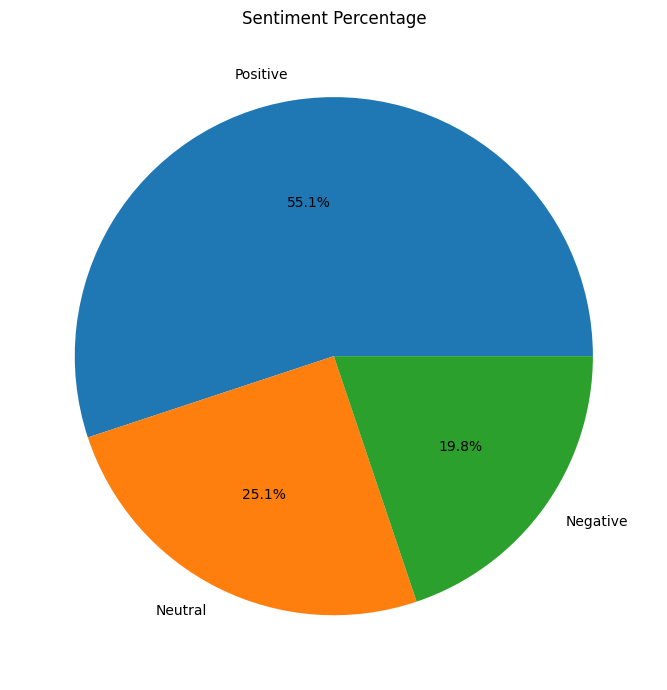

In [8]:
plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_percentage.values,
    labels=sentiment_percentage.index,
    autopct="%1.1f%%"
)
plt.title("Sentiment Percentage")
plt.tight_layout()
plt.show()

In [9]:
rating_by_sentiment = data.groupby("sentiment")["rating"].mean()

print(rating_by_sentiment)

sentiment
Negative    1.607507
Neutral     2.488804
Positive    3.957589
Name: rating, dtype: float64


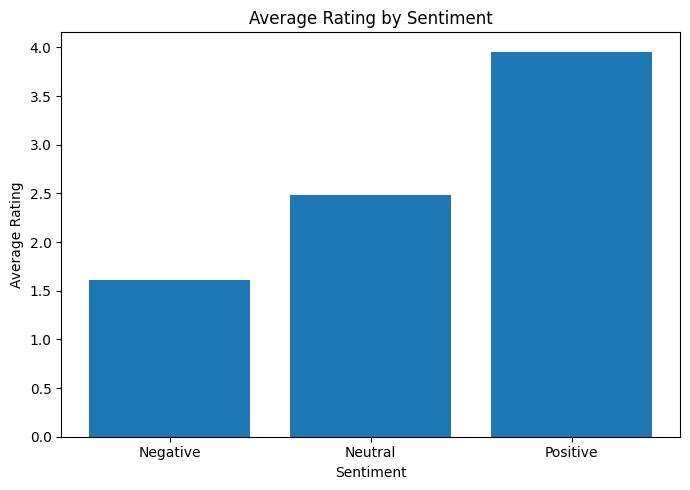

In [10]:
plt.figure(figsize=(7, 5))
plt.bar(rating_by_sentiment.index, rating_by_sentiment.values)
plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

In [11]:
#brand wise
brand_sentiment = pd.crosstab(data["brand"], data["sentiment"])

print(brand_sentiment.head())

sentiment  Negative  Neutral  Positive
brand                                 
Apple          1431     1764      3949
Google         1383     1852      3999
Motorola       1377     1856      3828
OnePlus        1434     1743      3959
Realme         1414     1745      3973


In [12]:
top_brands = data["brand"].value_counts().head(10).index

top_brand_data = data[data["brand"].isin(top_brands)]

brand_sentiment_top = pd.crosstab(
    top_brand_data["brand"],
    top_brand_data["sentiment"]
)

print(brand_sentiment_top)

sentiment  Negative  Neutral  Positive
brand                                 
Apple          1431     1764      3949
Google         1383     1852      3999
Motorola       1377     1856      3828
OnePlus        1434     1743      3959
Realme         1414     1745      3973
Samsung        1402     1778      3872
Xiaomi         1470     1811      3960


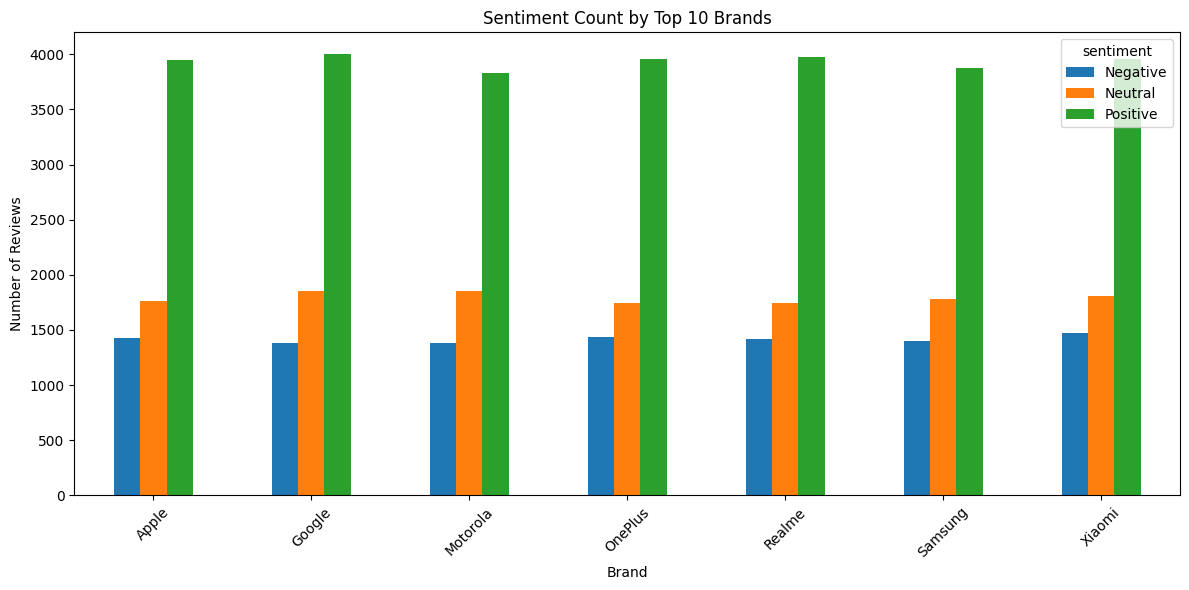

In [13]:
brand_sentiment_top.plot(kind="bar", figsize=(12, 6))

plt.title("Sentiment Count by Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Which brands have highest positive reviews?
brand_positive = data.groupby("brand").agg(
    total_reviews=("review_text", "count"),
    positive_reviews=("sentiment", lambda x: (x == "Positive").sum()),
    negative_reviews=("sentiment", lambda x: (x == "Negative").sum()),
    neutral_reviews=("sentiment", lambda x: (x == "Neutral").sum())
)

brand_positive["positive_percentage"] = (
    brand_positive["positive_reviews"] / brand_positive["total_reviews"] * 100
)

brand_positive = brand_positive.sort_values("positive_percentage", ascending=False)

print(brand_positive.head(10))

          total_reviews  positive_reviews  negative_reviews  neutral_reviews  \
brand                                                                          
Realme             7132              3973              1414             1745   
OnePlus            7136              3959              1434             1743   
Google             7234              3999              1383             1852   
Apple              7144              3949              1431             1764   
Samsung            7052              3872              1402             1778   
Xiaomi             7241              3960              1470             1811   
Motorola           7061              3828              1377             1856   

          positive_percentage  
brand                          
Realme              55.706674  
OnePlus             55.479260  
Google              55.280619  
Apple               55.277156  
Samsung             54.906410  
Xiaomi              54.688579  
Motorola            54.

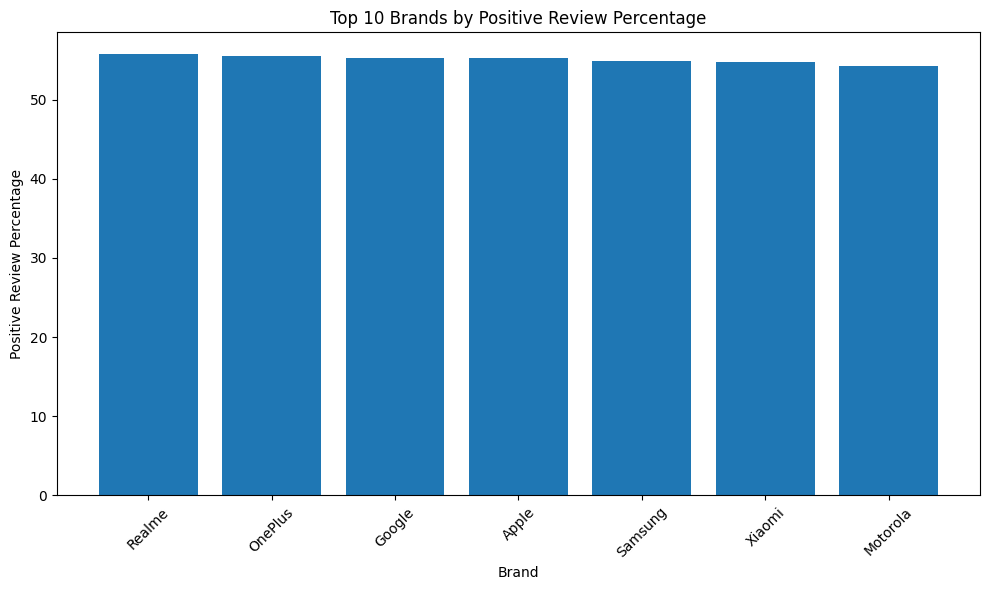

In [17]:
top_positive_brands = brand_positive.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_positive_brands.index, top_positive_brands["positive_percentage"])
plt.title("Top 10 Brands by Positive Review Percentage")
plt.xlabel("Brand")
plt.ylabel("Positive Review Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Which brands have highest negative reviews?
brand_negative = data.groupby("brand").agg(
    total_reviews=("review_text", "count"),
    negative_reviews=("sentiment", lambda x: (x == "Negative").sum())
)

brand_negative["negative_percentage"] = (
    brand_negative["negative_reviews"] / brand_negative["total_reviews"] * 100
)

brand_negative = brand_negative.sort_values("negative_percentage", ascending=False)

print(brand_negative.head(10))

          total_reviews  negative_reviews  negative_percentage
brand                                                         
Xiaomi             7241              1470            20.301063
OnePlus            7136              1434            20.095291
Apple              7144              1431            20.030795
Samsung            7052              1402            19.880885
Realme             7132              1414            19.826136
Motorola           7061              1377            19.501487
Google             7234              1383            19.118054


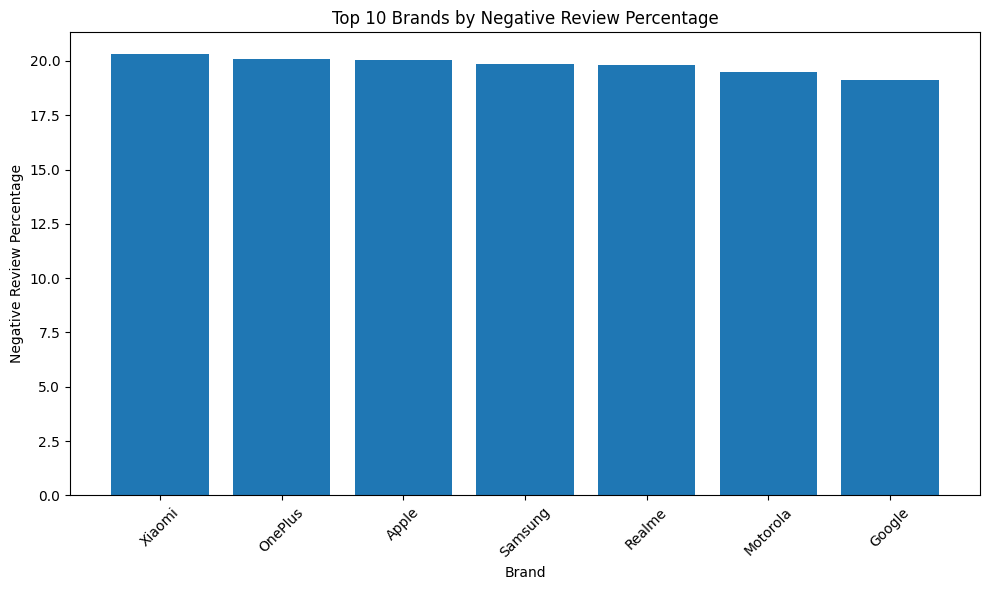

In [19]:
top_negative_brands = brand_negative.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_negative_brands.index, top_negative_brands["negative_percentage"])
plt.title("Top 10 Brands by Negative Review Percentage")
plt.xlabel("Brand")
plt.ylabel("Negative Review Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#Clean review text
data["clean_review"] = (
    data["review_text"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

data[["review_text", "clean_review"]].head()

,review_text,clean_review
0,Not worth the money spent. Wouldn’t recommend.,not worth the money spent wouldnt recommend
1,Absolutely love this phone! The camera is next...,absolutely love this phone the camera is next ...
2,Loving the clean UI and fast updates. Loving i...,loving the clean ui and fast updates loving it...
3,Build quality feels solid and durable. No regr...,build quality feels solid and durable no regre...
4,Not bad for daily use but could be optimized. ...,not bad for daily use but could be optimized a...


In [22]:
#Most common words in reviews
all_words = " ".join(data["clean_review"]).split()

stop_words = [
    "the", "is", "and", "a", "an", "to", "of", "for", "in", "on",
    "this", "that", "it", "with", "as", "was", "were", "be", "but",
    "not", "so", "very", "i", "my", "you", "are", "its", "at"
]

filtered_words = []

for word in all_words:
    if word not in stop_words and len(word) > 2:
        filtered_words.append(word)

word_count = pd.Series(filtered_words).value_counts().head(20)

print(word_count)

use           11148
worth         10640
loving         9754
absolutely     9556
best           8103
okay           7946
buying         7824
far            7004
year           6869
purchase       6869
one            6839
regrets        6839
could          6674
fast           6400
quality        5955
phone          5953
smooth         5539
feels          5507
overall        5482
better         5405
Name: count, dtype: int64


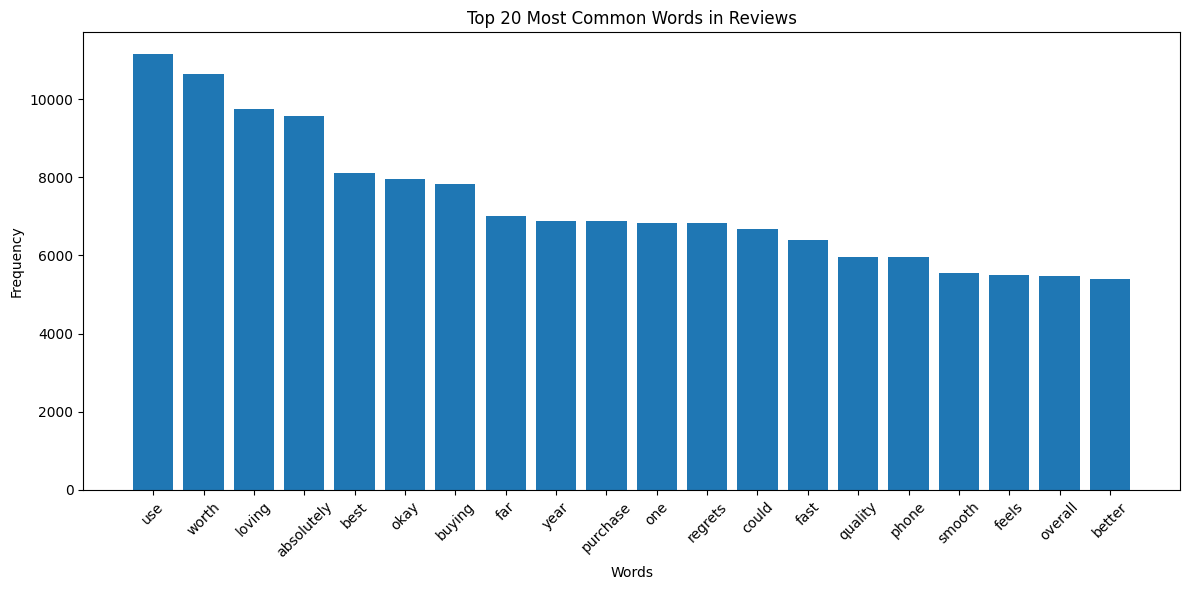

In [23]:
plt.figure(figsize=(12, 6))
plt.bar(word_count.index, word_count.values)
plt.title("Top 20 Most Common Words in Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
#Most common words in negative reviews
negative_reviews = data[data["sentiment"] == "Negative"]

negative_words = " ".join(negative_reviews["clean_review"]).split()

negative_filtered_words = []

for word in negative_words:
    if word not in stop_words and len(word) > 2:
        negative_filtered_words.append(word)

negative_word_count = pd.Series(negative_filtered_words).value_counts().head(20)

print(negative_word_count)

disappointed     2525
recommend        2472
wouldnt          2472
returning        2472
soon             2472
mark             2442
phone            1991
often            1991
quality          1954
after            1951
overheats        1048
quickly          1048
while            1048
gaming           1048
service          1041
customer         1041
disappointing    1041
spent            1025
worth            1025
money            1025
Name: count, dtype: int64


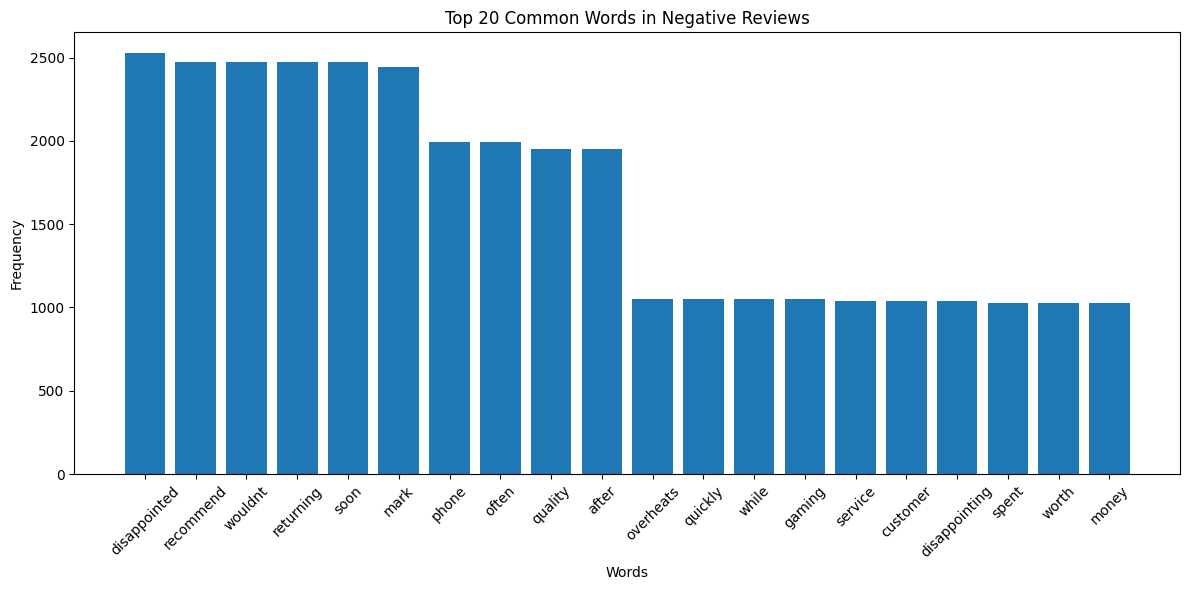

In [25]:
plt.figure(figsize=(12, 6))
plt.bar(negative_word_count.index, negative_word_count.values)
plt.title("Top 20 Common Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
#Most common words in positive reviews
positive_reviews = data[data["sentiment"] == "Positive"]

positive_words = " ".join(positive_reviews["clean_review"]).split()

positive_filtered_words = []

for word in positive_words:
    if word not in stop_words and len(word) > 2:
        positive_filtered_words.append(word)

positive_word_count = pd.Series(positive_filtered_words).value_counts().head(20)

print(positive_word_count)

loving         9754
worth          9615
absolutely     9556
far            7004
purchase       6869
year           6869
best           6869
one            6839
buying         6839
regrets        6839
use            5594
smooth         5539
feels          5507
fast           5462
months         2823
after          2823
performance    2823
even           2823
penny          2787
highly         2787
Name: count, dtype: int64


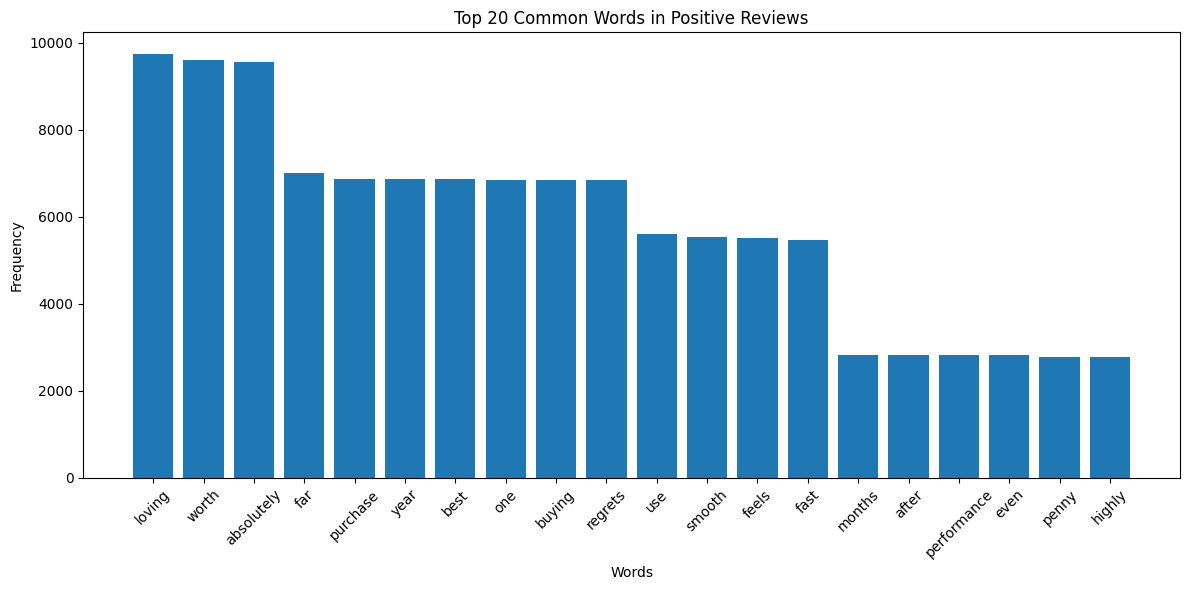

In [27]:
plt.figure(figsize=(12, 6))
plt.bar(positive_word_count.index, positive_word_count.values)
plt.title("Top 20 Common Words in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
#Simple lexicon-based sentiment prediction
positive_words = [
    "good", "great", "excellent", "amazing", "best", "love", "loved",
    "awesome", "perfect", "fast", "smooth", "beautiful", "nice",
    "worth", "recommend", "durable", "solid", "satisfied"
]

negative_words = [
    "bad", "poor", "worst", "hate", "hated", "slow", "terrible",
    "awful", "waste", "problem", "issues", "issue", "disappointed",
    "overpriced", "lag", "heating", "broken", "weak", "not"
]

def predict_sentiment(text):
    words = str(text).lower().split()

    positive_score = 0
    negative_score = 0

    for word in words:
        if word in positive_words:
            positive_score = positive_score + 1
        elif word in negative_words:
            negative_score = negative_score + 1

    if positive_score > negative_score:
        return "Positive"
    elif negative_score > positive_score:
        return "Negative"
    else:
        return "Neutral"

data["predicted_sentiment"] = data["clean_review"].apply(predict_sentiment)

data[["review_text", "sentiment", "predicted_sentiment"]].head(10)

,review_text,sentiment,predicted_sentiment
0,Not worth the money spent. Wouldn’t recommend.,Negative,Positive
1,Absolutely love this phone! The camera is next...,Positive,Positive
2,Loving the clean UI and fast updates. Loving i...,Positive,Positive
3,Build quality feels solid and durable. No regr...,Positive,Positive
4,Not bad for daily use but could be optimized. ...,Neutral,Negative
5,Battery easily lasts a day with heavy use. No ...,Positive,Neutral
6,Loving the clean UI and fast updates. Absolute...,Positive,Positive
7,"Phone hangs often, regret buying it. Wouldn’t ...",Negative,Positive
8,Battery easily lasts a day with heavy use. Lov...,Positive,Neutral
9,Smooth performance even after months of use. N...,Positive,Positive


In [31]:
# predictiion accuracy
correct_predictions = data["sentiment"] == data["predicted_sentiment"]

accuracy = correct_predictions.mean() * 100

print("Accuracy:", round(accuracy, 2), "%")

Accuracy: 79.89 %


In [32]:
confusion_table = pd.crosstab(
    data["sentiment"],
    data["predicted_sentiment"],
    rownames=["Actual Sentiment"],
    colnames=["Predicted Sentiment"]
)

print(confusion_table)

Predicted Sentiment  Negative  Neutral  Positive
Actual Sentiment                                
Negative                 5203     2726      1982
Neutral                  2531    10018         0
Positive                    0     2817     24723


In [33]:
data.to_csv("Task4_Mobile_Sentiment_Analysis_Result.csv", index=False)

print("File saved successfully")

File saved successfully
